In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy

In [2]:
# Hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 0.001
batch_size = 64
n_epochs = 5

In [3]:
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize(224), # ResNet expects 224x224 images
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    
    "val": transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [4]:
train_set = datasets.CIFAR10(root = "./data", train = True, download = True, transform = data_transforms["train"])

val_set = datasets.CIFAR10(root = "./data", train = False, download = True, transform = data_transforms["val"])

In [5]:
train_loader = DataLoader(train_set, batch_size = batch_size, shuffle = True)

val_loader = DataLoader(val_set, batch_size = batch_size, shuffle = False )

In [6]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss, total_acc = 0, 0
    for images, labels in tqdm(dataloader, desc = "Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        total_acc += torch.sum(preds == labels.data)
        
    return total_loss / len(dataloader.dataset), total_acc.double() / len(dataloader.dataset)

In [7]:
def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss, total_acc = 0, 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc = "Evaluating"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total_acc += torch.sum(preds == labels.data)
            
    return total_loss / len(dataloader.dataset), total_acc.double() / len(dataloader.dataset)

In [17]:
def plot_history(history, model_name):
    # Convert accuracy tensors to float (CPU) if needed
    def to_float_list(lst):
        return [x.cpu().item() if torch.is_tensor(x) else x for x in lst]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{model_name} - Loss Over Epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax2.plot(to_float_list(history['train_acc']), label='Train Accuracy')
    ax2.plot(to_float_list(history['val_acc']), label='Validation Accuracy')
    ax2.set_title(f'{model_name} - Accuracy Over Epochs')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    plt.show()

In [12]:
# Load the pre-trained model
print(f"\n--- Initializing model for Feature Extraction ---")

# Using the new recommended weights API
model_fe = models.resnet18(weights = models.ResNet18_Weights.DEFAULT)

# Freeze all the parameters in the network
# Key step for feature extraction
for param in model_fe.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
# Parameters of newly constructed modules have requires_grad = True by default
num_ftrs = model_fe.fc.in_features
model_fe.fc = nn.Linear(num_ftrs, 10)  # 10 classes for CIFAR10

# Move model to the device
model_fe = model_fe.to(device)


--- Initializing model for Feature Extraction ---


In [ ]:
optimizer = torch.optim.Adam(params = model_fe.fc.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

In [15]:
print(f"\n--- Starting Training: Feature Extraction ---")
history_fe = {"train_loss": [],
              "train_acc": [],
              "val_loss": [],
              "val_acc": []}

for epoch in range(n_epochs):
    print(f"\nEpoch {epoch + 1}/{n_epochs}")
    train_loss, train_acc = train_epoch(model = model_fe, dataloader = train_loader, optimizer = optimizer, criterion = criterion)
    
    val_loss, val_acc = evaluate(model = model_fe, dataloader = val_loader, criterion = criterion)
    
    history_fe["train_acc"].append(train_acc)
    history_fe["train_loss"].append(train_loss)
    history_fe["val_loss"].append(val_loss)
    history_fe["val_acc"].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")


--- Starting Training: Feature Extraction ---

Epoch 1/5


Evaluating: 100%|██████████| 157/157 [00:18<00:00,  8.27it/s]


Train Loss: 0.8272 | Train Acc: 73.03%
Val Loss: 0.6376 | Val Acc: 78.37%

Epoch 2/5


Evaluating: 100%|██████████| 157/157 [00:19<00:00,  7.89it/s]


Train Loss: 0.6250 | Train Acc: 78.46%
Val Loss: 0.6006 | Val Acc: 79.21%

Epoch 3/5


...

Train Loss: 0.5925 | Train Acc: 79.47%
Val Loss: 0.5848 | Val Acc: 80.32%

Epoch 4/5


Evaluating: 100%|██████████| 157/157 [00:48<00:00,  3.27it/s]


Train Loss: 0.5809 | Train Acc: 79.89%
Val Loss: 0.5792 | Val Acc: 80.22%

Epoch 5/5


Evaluating: 100%|██████████| 157/157 [00:19<00:00,  7.95it/s]

Train Loss: 0.5686 | Train Acc: 80.29%
Val Loss: 0.5668 | Val Acc: 80.69%


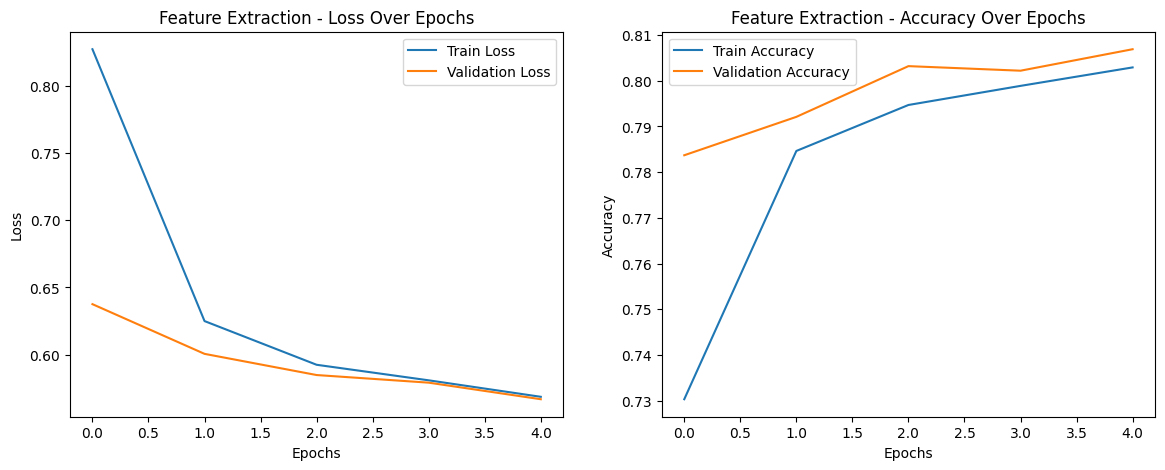

In [18]:
plot_history(history_fe, "Feature Extraction")